
===== DATASET OVERVIEW =====
   age     sex   bmi  children smoker     region   charges
0   56    male  26.7         1     no  southwest  23259.46
1   46  female  41.3         2     no  southwest  26200.30
2   32  female  21.3         4     no  northeast  13491.81
3   60  female  16.8         4     no  southwest  25169.32
4   25    male  32.6         3    yes  northeast  50372.05
               age          bmi     children       charges
count  1000.000000  1000.000000  1000.000000   1000.000000
mean     40.986000    30.342500     2.439000  26046.749670
std      13.497852     6.003616     1.710323  11267.442951
min      18.000000    12.500000     0.000000   7030.270000
25%      29.000000    26.300000     1.000000  18483.747500
50%      42.000000    30.250000     2.000000  22559.645000
75%      52.000000    34.300000     4.000000  28014.075000
max      64.000000    49.200000     5.000000  60454.080000

===== MISSING VALUES =====
age         0
sex         0
bmi         0
children    0
s

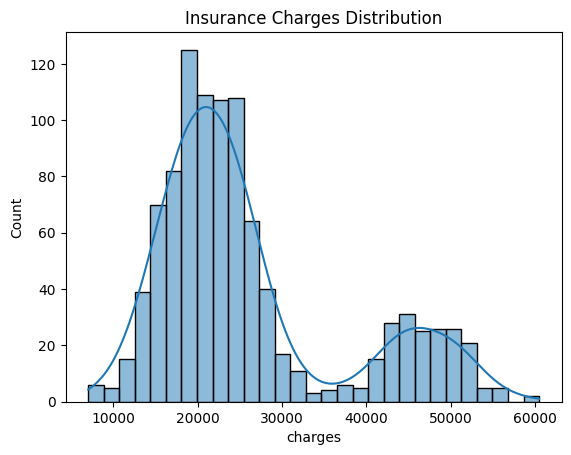

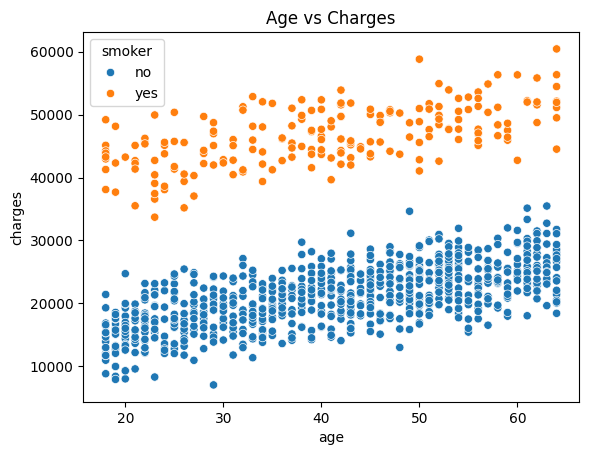

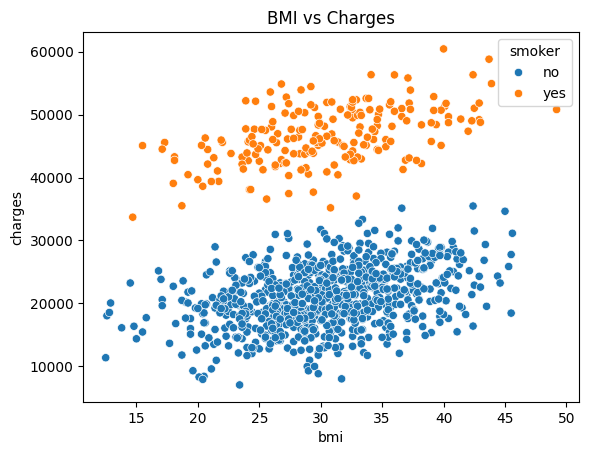

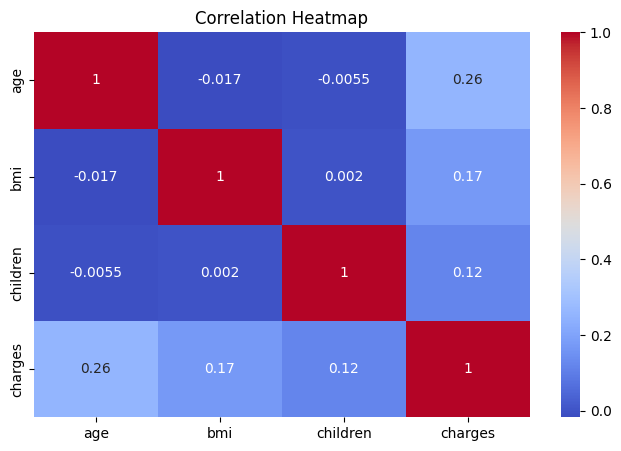


===== SIMPLE LINEAR REGRESSION =====
R2: 0.06703785133231288
MAE: 8489.042448177242
MSE: 120569350.9471344
RMSE: 10980.407594763248

===== MULTIPLE LINEAR REGRESSION =====
R2: 0.9272125271038533
MAE: 2500.764213629342
MSE: 9406532.0621024
RMSE: 3067.0070202238535

===== LOGISTIC REGRESSION =====
Accuracy: 0.865
Confusion Matrix:
 [[90 10]
 [17 83]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       100
           1       0.89      0.83      0.86       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200




Project Executed Successfully.


In [1]:

"""
Medical Insurance Cost Analysis and Prediction System
Single-file project with embedded synthetic insurance dataset.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, classification_report
)

np.random.seed(42)

def generate_dataset(n=1000):
    age = np.random.randint(18, 65, n)
    sex = np.random.choice(['male', 'female'], n)
    bmi = np.round(np.random.normal(30, 6, n), 1)
    children = np.random.randint(0, 6, n)
    smoker = np.random.choice(['yes', 'no'], n, p=[0.2, 0.8])
    region = np.random.choice(
        ['northeast', 'northwest', 'southeast', 'southwest'], n
    )

    charges = (
        age * 220 +
        bmi * 350 +
        children * 600 +
        np.where(smoker == 'yes', 25000, 0) +
        np.random.normal(0, 3000, n)
    )

    return pd.DataFrame({
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region,
        "charges": np.round(charges, 2)
    })

df = generate_dataset()

print("\n===== DATASET OVERVIEW =====")
print(df.head())
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== AVERAGES =====")
print("Average Age:", round(df.age.mean(), 2))
print("Average BMI:", round(df.bmi.mean(), 2))
print("Average Children:", round(df.children.mean(), 2))
print("Average Charges:", round(df.charges.mean(), 2))

# Risk Categories
q1 = df.charges.quantile(0.33)
q2 = df.charges.quantile(0.66)

def risk(x):
    if x <= q1:
        return "Low Cost"
    elif x <= q2:
        return "Medium Cost"
    return "High Cost"

df["risk_category"] = df["charges"].apply(risk)

# Visualizations
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Charges")
plt.show()

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Encoding
data = pd.get_dummies(
    df[["age","sex","bmi","children","smoker","region","charges"]],
    drop_first=True
)

# Simple Linear Regression
X = df[["age"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("\n===== SIMPLE LINEAR REGRESSION =====")
print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

# Multiple Linear Regression
X = data.drop("charges", axis=1)
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

pred2 = mlr.predict(X_test)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("R2:", r2_score(y_test, pred2))
print("MAE:", mean_absolute_error(y_test, pred2))
print("MSE:", mean_squared_error(y_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred2)))

# Logistic Regression
median_charge = df["charges"].median()
df["insurance_category"] = np.where(
    df["charges"] >= median_charge, 1, 0
)

cls = pd.get_dummies(
    df[["age","bmi","children","smoker"]],
    drop_first=True
)

X = cls
y = df["insurance_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

pred3 = log_model.predict(X_test)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred3))
print(classification_report(y_test, pred3))

# Plotly Dashboard Charts
fig1 = px.histogram(df, x="charges", title="Charges Distribution")
fig2 = px.scatter(df, x="age", y="charges", color="smoker",
                  title="Age vs Charges")
fig3 = px.scatter(df, x="bmi", y="charges", color="smoker",
                  title="BMI vs Charges")
fig4 = px.box(df, x="region", y="charges",
              title="Region Wise Charges")

fig1.show()
fig2.show()
fig3.show()
fig4.show()

print("\nProject Executed Successfully.")
